# **HospitalityGPT - Industry-Specific Hospitality Customer Support Chatbot**

## **Project Objective**

The objective of this project is to develop a domain-specific conversational AI assistant for the Hospitality industry using a pre-trained Large Language Model (LLM). The chatbot is designed to assist customers with common hospitality-related inquiries such as hotel reservations, room availability, check-in and check-out procedures, cancellations, amenities, payments, dining services, and general guest support.

The project demonstrates how Large Language Models can be adapted to a specialized business domain through supervised fine-tuning, Retrieval-Augmented Generation (RAG), and semantic search.

---

## **Key Features**

- Industry-specific Hospitality customer support chatbot
- Fine-tuned TinyLlama 1.1B Chat model using LoRA
- Retrieval-Augmented Generation (RAG)
- FAISS vector database for semantic retrieval
- Sentence Transformer embeddings
- Interactive Gradio chatbot interface

---

## **Technology Stack**

- Python
- Google Colab (T4 GPU)
- Hugging Face Transformers
- TinyLlama 1.1B Chat
- PEFT (LoRA)
- Sentence Transformers
- FAISS
- Gradio

**Environment Setup**

In this section, all required libraries are installed for data preprocessing, exploratory data analysis, model fine-tuning, semantic retrieval, and chatbot deployment.

The project is developed using Google Colab with GPU acceleration to efficiently train and deploy the HospitalityGPT model.

In [1]:
!pip install -q transformers datasets peft accelerate bitsandbytes trl \
sentence-transformers faiss-cpu gradio evaluate rouge-score nltk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.4 MB/s eta 0:00:00


**Mount Google Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Create Project Directory Structure**

In [4]:
import os

BASE_PATH = "/content/drive/MyDrive/Module_6_Specialization_NLP/HospitalityGPT"

DATA_PATH = f"{BASE_PATH}/data"
MODEL_PATH = f"{BASE_PATH}/models"
OUTPUT_PATH = f"{BASE_PATH}/outputs"
EVAL_PATH = f"{BASE_PATH}/evaluation"
RAG_PATH = f"{BASE_PATH}/rag"

for folder in [DATA_PATH, MODEL_PATH, OUTPUT_PATH, EVAL_PATH, RAG_PATH]:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


**Import Required Libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth", None)

**Load the Hospitality Dataset**

This dataset contains real-world hospitality customer support conversations covering various service areas such as reservations, billing, cancellations, amenities, payments, room services, and general guest assistance.

The dataset also includes intent labels and business categories that can be leveraged during exploratory analysis and semantic retrieval.

In [7]:
dataset_path = f"{BASE_PATH}/bitext-hospitality-llm-chatbot-training-dataset.csv"

hospitality_df = pd.read_csv(dataset_path)

print(f"Dataset Shape: {hospitality_df.shape}")

hospitality_df.head()

Dataset Shape: (25000, 5)


,instruction,intent,category,tags,response
0,I'm looking for informtion about my fucking invoices where can i find it,invoices,BILLING,BCEIQWZ,"To obtain your invoices online, please follow these steps:\n\n1. Visit {{WEBSITE_URL}} and log into your account by entering your username and password.\n2. Locate the {{INVOICES_SECTION}} which houses all your billing documents.\n3. Choose the particular invoice or date range you wish to view.\n4. Save or print the invoice as required.\n\nShould you have any additional inquiries or concerns, please feel free to contact customer support via the communication methods available on our website."
1,wanna check my invocies where could i do it,invoices,BILLING,BCIPQZ,"To review your invoices online, please adhere to the following steps:\n\n1. Navigate to {{WEBSITE_URL}} and log into your account by entering your username and password.\n2. Locate the {{INVOICES_SECTION}} which houses all your billing documents.\n3. Choose the particular invoice or date range you wish to examine.\n4. Save or print the invoice as required.\n\nShould you require additional assistance or encounter any difficulties, do not hesitate to contact customer support via the available channels on our website."
2,I'd like to see my invoices how cn i do it,invoices,BILLING,BCILPQZ,"To view your invoices conveniently on our platform, please adhere to the following steps: \n\n1. Go to {{WEBSITE_URL}} and log into your account by entering your username and password. \n2. Locate the {{INVOICES_SECTION}} which houses all your billing documents. \n3. Choose the particular invoice or date range you wish to examine. \n4. Save or print the invoice as required. \n\nIf you require any further assistance or encounter any concerns, please feel free to contact customer support via the communication methods available on our site."
3,"I need to check my fucking invoices, how could I do iot?",invoices,BILLING,BCIPWZ,"To access your invoices online, please adhere to the following steps:\n\n1. Go to {{WEBSITE_URL}} and log in to your account using your username and password.\n2. Locate the {{INVOICES_SECTION}}, where all your invoices are maintained.\n3. Choose the desired invoice by specifying the relevant date range or invoice number.\n4. Save or print the invoice as required for your records.\n\nShould you require any additional assistance or face any difficulties, please contact our customer support for further help through the options provided on our website."
4,"I can't find my bills, can I get them?",invoices,BILLING,BCILM,"To retrieve your invoices online, please follow these instructions: \n\n1. Access {{WEBSITE_URL}} and enter your account credentials to log in. \n2. Go to the {{INVOICES_SECTION}}, which contains all your payment documents. \n3. Choose the invoice by specifying the relevant date range or invoice reference. \n4. Save or print the invoice as you require. \n\nShould you need any assistance or encounter any difficulties, please feel free to reach out to customer support via the contact methods available on our site."


### **Explore the Dataset**

Before preprocessing, it is important to understand the dataset structure and identify any potential quality issues.

The following exploratory analysis examines:

- Dataset dimensions
- Column information
- Missing values
- Duplicate records
- Distribution of business categories
- Distribution of customer intents
- Sample customer conversations

In [8]:
hospitality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   instruction  25000 non-null  object
 1   intent       25000 non-null  object
 2   category     25000 non-null  object
 3   tags         25000 non-null  object
 4   response     25000 non-null  object
dtypes: object(5)
memory usage: 976.7+ KB


In [9]:
hospitality_df.describe(include="object").T

,count,unique,top,freq
instruction,25000,24995,I'm looking for information about the fucking check-out,2
intent,25000,25,invoices,1000
category,25000,16,HOTEL,8000
tags,25000,356,BCILPWZ,845
response,25000,13223,"To connect with a human agent for assistance, please follow these outlined steps:\n\n1. Access our official website at {{WEBSITE_URL}}.\n2. Locate the {{CONTACT_US_SECTION}} on the site.\n3. Choose the option to {{SPEAK_WITH_HUMAN_AGENT_OPTION}}.\n4. Complete any necessary fields and submit your inquiry.\n\nShould you require further support, please do not hesitate to reach out using the contact information provided.",126


In [10]:
hospitality_df.isnull().sum()

,0
instruction,0
intent,0
category,0
tags,0
response,0


In [11]:
print("Duplicate Rows:", hospitality_df.duplicated().sum())

Duplicate Rows: 0


**Distribution of Business Categories**

Understanding the distribution of categories helps identify whether the dataset is balanced or dominated by a few hospitality services.

category
HOTEL                8000
CONTACT              2000
FEEDBACK             2000
BILLING              1000
CHECK_OUT            1000
CHECK_IN             1000
CANCELLATION_FEES    1000
EVENT                1000
LUGGAGE              1000
MENU                 1000
NIGHT                1000
PARKING_SPACE        1000
PETS                 1000
POINTS               1000
REFUND               1000
SHUTTLE_SERVICE      1000
Name: count, dtype: int64


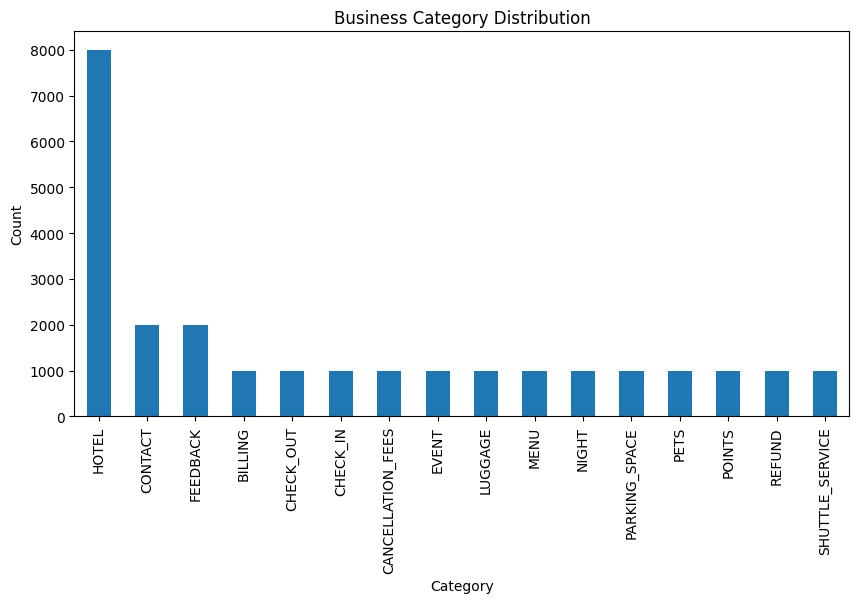

In [12]:
category_counts = hospitality_df["category"].value_counts()

print(category_counts)

plt.figure(figsize=(10,5))
category_counts.plot(kind="bar")
plt.title("Business Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

**Distribution of Customer Intents**

The intent labels represent the primary purpose of each customer query.

Analyzing their frequency provides insight into the diversity of customer requests contained in the dataset.

intent
invoices                    1000
cancellation_fees           1000
check_in                    1000
check_out                   1000
customer_service            1000
human_agent                 1000
host_event                  1000
file_complaint              1000
leave_review                1000
book_hotel                  1000
cancel_hotel_reservation    1000
change_hotel_reservation    1000
check_hotel_facilities      1000
check_hotel_offers          1000
check_hotel_prices          1000
check_hotel_reservation     1000
search_hotel                1000
store_luggage               1000
check_menu                  1000
add_night                   1000
Name: count, dtype: int64


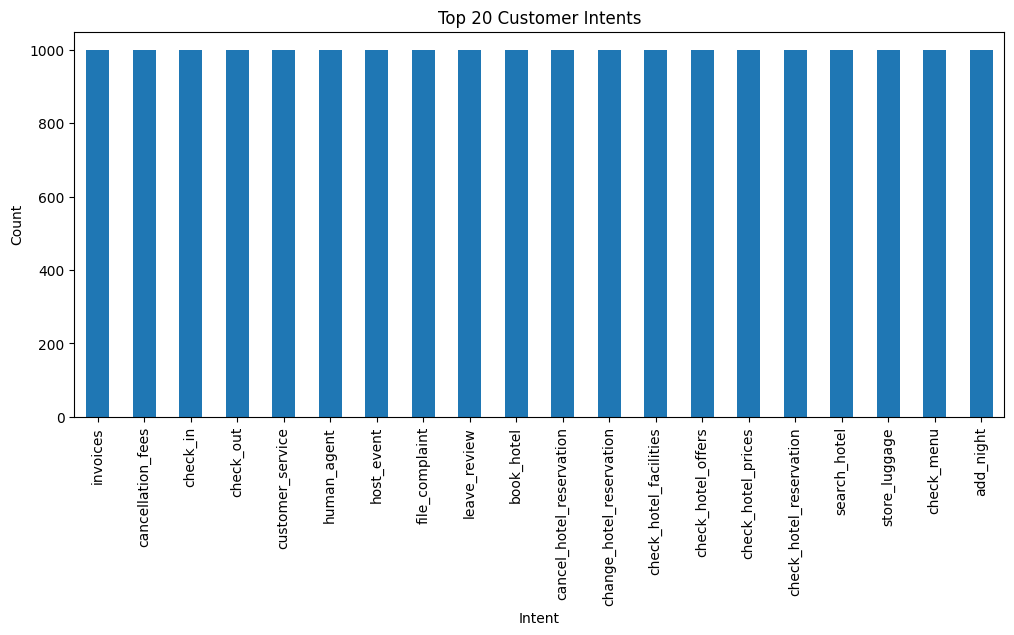

In [13]:
intent_counts = hospitality_df["intent"].value_counts()

print(intent_counts.head(20))

plt.figure(figsize=(12,5))
intent_counts.head(20).plot(kind="bar")
plt.title("Top 20 Customer Intents")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.show()

In [14]:
hospitality_df.sample(5)[["instruction","intent","category","response"]]

,instruction,intent,category,response
22780,"I got to use my fucking loyalty points, where can I do it?",redeem_points,POINTS,"To redeem your {{POINTS_TYPE}}, please proceed with the following instructions:\n\n1. Access your account by visiting {{WEBSITE_URL}}.\n2. Locate the {{REDEEM_POINTS_SECTION}} dedicated to your loyalty points management.\n3. Opt for the redeem points option available.\n4. Specify the reward or service you intend to redeem your points for.\n5. Verify your selection and follow the instructions to finalize the redemption process.\n\nShould you face any difficulties, do not hesitate to reach out to our customer service for further support."
24730,"I have to make a booking for a fucking shuttle service from the bus station, could I get some help?",shuttle_service,SHUTTLE_SERVICE,"To obtain further details regarding our shuttle service from {{ORIGIN}}, please adhere to the outlined steps below: \n\n1. Access our website at {{WEBSITE_URL}}. \n2. Proceed to the {{SERVICES_SECTION}} and select {{SHUTTLE_SERVICE}}. \n3. Input the required origin and destination information. \n4. Examine the options available and select your desired service. \n5. For any further questions, please reach out to our customer support at {{SUPPORT_INFORMATION}}. \n\nWe are committed to providing you with the necessary assistance for your travel arrangements."
7684,i aint happy with the fucking accommodation could ya help me to submit a complaint,file_complaint,FEEDBACK,"We acknowledge the difficulties you have faced and are here to guide you through the complaint submission process.\n\n1. Access the hotel's official website at {{WEBSITE_URL}}.\n2. Proceed to the {{CONTACT_US_SECTION}}.\n3. Find the complaint form and input the necessary details including your name, reservation number, and a comprehensive account of the issue encountered.\n4. If relevant, attach any necessary documentation or images that support your complaint.\n5. Send the form and remember to keep the reference number for any future inquiries.\n\nYour feedback is valuable to us, and we assure you that the hotel management will investigate your concerns thoroughly."
9463,"I need to make a booking for a room in Madrid, where do I do it?",book_hotel,HOTEL,"To assist you in securing a hotel room in {{DESTINATION_CITY}}, please adhere to the following steps:\n\n1. Navigate to the website {{WEBSITE_URL}}.\n2. Enter {{DESTINATION_CITY}} in the designated search field.\n3. Input your check-in and check-out dates.\n4. Specify the number of rooms and types you require.\n5. Press the {{SEARCH_BUTTON}} to explore available accommodations.\n6. Examine the proposed options and select your preferred hotel.\n7. Follow the instructions displayed on the screen to finalize your reservation.\n\nShould you require further assistance at any point during this process, please do not hesitate to inquire."
8397,wanna leave a comment about the hotel how can i do it,leave_review,FEEDBACK,We appreciate your decision to share your thoughts regarding your recent experience at our hotel. Your feedback is crucial in helping us enhance our services.\n\n1. Please visit our official website at {{WEBSITE_URL}}.\n2. Proceed to the {{REVIEW_SECTION}}.\n3. Find the option labeled {{LEAVE_REVIEW_OPTION}}.\n4. Complete the necessary fields along with your review.\n5. Submit your review for consideration by our management team.\n\nYour insights are invaluable in guiding us to provide improved experiences for our future guests. Thank you for taking the time to contribute your feedback.


### **Data Cleaning and Preprocessing**

High-quality training data is essential for building an effective conversational AI system.

In this step, the dataset is cleaned by:

- Removing HTML tags
- Removing URLs
- Eliminating unnecessary whitespace
- Removing duplicate records
- Removing missing values

The cleaned dataset provides a more consistent input for model fine-tuning while preserving the original meaning of customer queries and responses.

In [15]:
def clean_text(text):
    """
    Clean text by removing HTML tags, URLs, and extra whitespace.
    """

    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [16]:
hospitality_df["instruction"] = hospitality_df["instruction"].apply(clean_text)
hospitality_df["response"] = hospitality_df["response"].apply(clean_text)

hospitality_df.head()

,instruction,intent,category,tags,response
0,I'm looking for informtion about my fucking invoices where can i find it,invoices,BILLING,BCEIQWZ,"To obtain your invoices online, please follow these steps: 1. Visit {{WEBSITE_URL}} and log into your account by entering your username and password. 2. Locate the {{INVOICES_SECTION}} which houses all your billing documents. 3. Choose the particular invoice or date range you wish to view. 4. Save or print the invoice as required. Should you have any additional inquiries or concerns, please feel free to contact customer support via the communication methods available on our website."
1,wanna check my invocies where could i do it,invoices,BILLING,BCIPQZ,"To review your invoices online, please adhere to the following steps: 1. Navigate to {{WEBSITE_URL}} and log into your account by entering your username and password. 2. Locate the {{INVOICES_SECTION}} which houses all your billing documents. 3. Choose the particular invoice or date range you wish to examine. 4. Save or print the invoice as required. Should you require additional assistance or encounter any difficulties, do not hesitate to contact customer support via the available channels on our website."
2,I'd like to see my invoices how cn i do it,invoices,BILLING,BCILPQZ,"To view your invoices conveniently on our platform, please adhere to the following steps: 1. Go to {{WEBSITE_URL}} and log into your account by entering your username and password. 2. Locate the {{INVOICES_SECTION}} which houses all your billing documents. 3. Choose the particular invoice or date range you wish to examine. 4. Save or print the invoice as required. If you require any further assistance or encounter any concerns, please feel free to contact customer support via the communication methods available on our site."
3,"I need to check my fucking invoices, how could I do iot?",invoices,BILLING,BCIPWZ,"To access your invoices online, please adhere to the following steps: 1. Go to {{WEBSITE_URL}} and log in to your account using your username and password. 2. Locate the {{INVOICES_SECTION}}, where all your invoices are maintained. 3. Choose the desired invoice by specifying the relevant date range or invoice number. 4. Save or print the invoice as required for your records. Should you require any additional assistance or face any difficulties, please contact our customer support for further help through the options provided on our website."
4,"I can't find my bills, can I get them?",invoices,BILLING,BCILM,"To retrieve your invoices online, please follow these instructions: 1. Access {{WEBSITE_URL}} and enter your account credentials to log in. 2. Go to the {{INVOICES_SECTION}}, which contains all your payment documents. 3. Choose the invoice by specifying the relevant date range or invoice reference. 4. Save or print the invoice as you require. Should you need any assistance or encounter any difficulties, please feel free to reach out to customer support via the contact methods available on our site."


In [17]:
before_rows = len(hospitality_df)

hospitality_df.drop_duplicates(inplace=True)
hospitality_df.dropna(inplace=True)

after_rows = len(hospitality_df)

print(f"Rows before cleaning : {before_rows}")
print(f"Rows after cleaning  : {after_rows}")
print(f"Rows removed         : {before_rows-after_rows}")

Rows before cleaning : 25000
Rows after cleaning  : 25000
Rows removed         : 0


### **Preparing the Dataset for Fine-Tuning**

The original dataset contains additional metadata such as intent labels, categories, and tags.

These fields are valuable for exploratory analysis and retrieval but are not required for supervised fine-tuning.

For model training, the dataset is converted into the standard Instruction-Input-Output format commonly used for instruction-tuned Large Language Models.

In [18]:
training_df = hospitality_df.rename(
    columns={
        "response": "output"
    }
)

training_df["input"] = ""

training_df = training_df[
    [
        "instruction",
        "input",
        "output",
        "intent",
        "category"
    ]
]

training_df.head()

,instruction,input,output,intent,category
0,I'm looking for informtion about my fucking invoices where can i find it,,"To obtain your invoices online, please follow these steps: 1. Visit {{WEBSITE_URL}} and log into your account by entering your username and password. 2. Locate the {{INVOICES_SECTION}} which houses all your billing documents. 3. Choose the particular invoice or date range you wish to view. 4. Save or print the invoice as required. Should you have any additional inquiries or concerns, please feel free to contact customer support via the communication methods available on our website.",invoices,BILLING
1,wanna check my invocies where could i do it,,"To review your invoices online, please adhere to the following steps: 1. Navigate to {{WEBSITE_URL}} and log into your account by entering your username and password. 2. Locate the {{INVOICES_SECTION}} which houses all your billing documents. 3. Choose the particular invoice or date range you wish to examine. 4. Save or print the invoice as required. Should you require additional assistance or encounter any difficulties, do not hesitate to contact customer support via the available channels on our website.",invoices,BILLING
2,I'd like to see my invoices how cn i do it,,"To view your invoices conveniently on our platform, please adhere to the following steps: 1. Go to {{WEBSITE_URL}} and log into your account by entering your username and password. 2. Locate the {{INVOICES_SECTION}} which houses all your billing documents. 3. Choose the particular invoice or date range you wish to examine. 4. Save or print the invoice as required. If you require any further assistance or encounter any concerns, please feel free to contact customer support via the communication methods available on our site.",invoices,BILLING
3,"I need to check my fucking invoices, how could I do iot?",,"To access your invoices online, please adhere to the following steps: 1. Go to {{WEBSITE_URL}} and log in to your account using your username and password. 2. Locate the {{INVOICES_SECTION}}, where all your invoices are maintained. 3. Choose the desired invoice by specifying the relevant date range or invoice number. 4. Save or print the invoice as required for your records. Should you require any additional assistance or face any difficulties, please contact our customer support for further help through the options provided on our website.",invoices,BILLING
4,"I can't find my bills, can I get them?",,"To retrieve your invoices online, please follow these instructions: 1. Access {{WEBSITE_URL}} and enter your account credentials to log in. 2. Go to the {{INVOICES_SECTION}}, which contains all your payment documents. 3. Choose the invoice by specifying the relevant date range or invoice reference. 4. Save or print the invoice as you require. Should you need any assistance or encounter any difficulties, please feel free to reach out to customer support via the contact methods available on our site.",invoices,BILLING


### **Create a Custom Hospitality FAQ Dataset**

Although the Bitext Hospitality dataset already contains a large number of customer support conversations, additional Frequently Asked Questions (FAQs) are manually created to improve coverage of common hospitality scenarios.

These examples help strengthen the chatbot's understanding of practical guest inquiries that frequently occur in hotels, resorts, and hospitality businesses.

Adding custom domain-specific examples also improves the diversity of the training data.

In [19]:
# Custom Hospitality FAQ Dataset

faq_data = [

    {
        "instruction": "How can I book a room?",
        "input": "",
        "output": "You can book a room through our website, mobile app, or by contacting our reservations team.",
        "intent": "room_booking",
        "category": "RESERVATION"
    },

    {
        "instruction": "Can I cancel my reservation?",
        "input": "",
        "output": "Reservations may be cancelled according to the cancellation policy applicable to your booking.",
        "intent": "reservation_cancellation",
        "category": "RESERVATION"
    },

    {
        "instruction": "Can I modify my reservation?",
        "input": "",
        "output": "Yes. Reservation changes are subject to room availability and applicable booking conditions.",
        "intent": "modify_booking",
        "category": "RESERVATION"
    },

    {
        "instruction": "What time is check-in?",
        "input": "",
        "output": "Standard check-in begins at the hotel's scheduled check-in time. Early check-in may be available depending on room availability.",
        "intent": "check_in",
        "category": "FRONT_DESK"
    },

    {
        "instruction": "What time is check-out?",
        "input": "",
        "output": "Standard check-out is at the hotel's scheduled check-out time. Late check-out may be available upon request.",
        "intent": "check_out",
        "category": "FRONT_DESK"
    },

    {
        "instruction": "Can I request an early check-in?",
        "input": "",
        "output": "Early check-in requests are accommodated based on room availability and cannot be guaranteed.",
        "intent": "early_checkin",
        "category": "FRONT_DESK"
    },

    {
        "instruction": "Can I request a late check-out?",
        "input": "",
        "output": "Late check-out may be available depending on occupancy and may involve additional charges.",
        "intent": "late_checkout",
        "category": "FRONT_DESK"
    },

    {
        "instruction": "Do you provide free Wi-Fi?",
        "input": "",
        "output": "Most rooms include complimentary Wi-Fi. Please check your booking details for confirmation.",
        "intent": "wifi",
        "category": "AMENITIES"
    },

    {
        "instruction": "Is breakfast included?",
        "input": "",
        "output": "Breakfast inclusion depends on your room package and booking plan.",
        "intent": "breakfast",
        "category": "DINING"
    },

    {
        "instruction": "Do you have room service?",
        "input": "",
        "output": "Yes, room service is available during designated operating hours.",
        "intent": "room_service",
        "category": "DINING"
    },

    {
        "instruction": "Do you have a restaurant?",
        "input": "",
        "output": "Yes. Our hotel restaurant serves a variety of local and international cuisine.",
        "intent": "restaurant",
        "category": "DINING"
    },

    {
        "instruction": "Do you have vegetarian food?",
        "input": "",
        "output": "Yes, vegetarian meal options are available at our restaurant.",
        "intent": "restaurant_food",
        "category": "DINING"
    },

    {
        "instruction": "Is parking available?",
        "input": "",
        "output": "Parking facilities are available for guests. Charges may apply depending on the property.",
        "intent": "parking",
        "category": "AMENITIES"
    },

    {
        "instruction": "Is airport shuttle service available?",
        "input": "",
        "output": "Airport shuttle service may be available at selected properties. Please contact the hotel before arrival.",
        "intent": "airport_transfer",
        "category": "TRANSPORT"
    },

    {
        "instruction": "Can I bring my pet?",
        "input": "",
        "output": "Pet policies vary by property. Please verify whether pets are permitted before booking.",
        "intent": "pets",
        "category": "HOTEL_POLICY"
    },

    {
        "instruction": "Do you allow smoking?",
        "input": "",
        "output": "Smoking policies depend on the hotel. Designated smoking areas may be available.",
        "intent": "smoking",
        "category": "HOTEL_POLICY"
    },

    {
        "instruction": "Can I request an extra bed?",
        "input": "",
        "output": "Extra beds are subject to room type availability and may incur additional charges.",
        "intent": "extra_bed",
        "category": "ROOM"
    },

    {
        "instruction": "Can I upgrade my room?",
        "input": "",
        "output": "Room upgrades are offered based on availability and may require an additional payment.",
        "intent": "room_upgrade",
        "category": "ROOM"
    },

    {
        "instruction": "Do you have a swimming pool?",
        "input": "",
        "output": "Swimming pool availability depends on the property. Please check the hotel amenities before booking.",
        "intent": "swimming_pool",
        "category": "AMENITIES"
    },

    {
        "instruction": "Do you have a gym?",
        "input": "",
        "output": "Many of our hotels provide fitness centers for guests.",
        "intent": "gym",
        "category": "AMENITIES"
    },

    {
        "instruction": "Is there a spa?",
        "input": "",
        "output": "Spa services are available at selected hotels and may require prior appointments.",
        "intent": "spa",
        "category": "AMENITIES"
    },

    {
        "instruction": "Can I store my luggage before check-in?",
        "input": "",
        "output": "Yes. Luggage storage is usually available before check-in and after check-out.",
        "intent": "luggage",
        "category": "FRONT_DESK"
    },

    {
        "instruction": "Do you provide laundry services?",
        "input": "",
        "output": "Laundry and dry-cleaning services are available at many properties.",
        "intent": "laundry",
        "category": "SERVICES"
    },

    {
        "instruction": "How do I request housekeeping?",
        "input": "",
        "output": "Housekeeping requests can be made through the front desk or guest services.",
        "intent": "housekeeping",
        "category": "SERVICES"
    },

    {
        "instruction": "Can I get an invoice for my stay?",
        "input": "",
        "output": "Yes. You can request an invoice during check-out or download it from your account if available.",
        "intent": "invoice",
        "category": "BILLING"
    },

    {
        "instruction": "What payment methods are accepted?",
        "input": "",
        "output": "Most hotels accept major credit cards, debit cards, and selected digital payment methods.",
        "intent": "payment",
        "category": "PAYMENT"
    },

    {
        "instruction": "How long does a refund take?",
        "input": "",
        "output": "Refund processing times depend on the payment provider and applicable cancellation policy.",
        "intent": "refund",
        "category": "PAYMENT"
    },

    {
        "instruction": "Can I book multiple rooms?",
        "input": "",
        "output": "Yes. Multiple rooms can be booked together depending on availability.",
        "intent": "group_booking",
        "category": "RESERVATION"
    },

    {
        "instruction": "Do you offer accessible rooms?",
        "input": "",
        "output": "Accessible rooms are available at many hotels. Please request them while making your reservation.",
        "intent": "accessible_room",
        "category": "ROOM"
    },

    {
        "instruction": "How can I contact customer support?",
        "input": "",
        "output": "Customer support can be contacted through our website, mobile app, email, or phone.",
        "intent": "customer_support",
        "category": "SUPPORT"
    }

]

faq_df = pd.DataFrame(faq_data)

print(f"Custom FAQ Records: {len(faq_df)}")

faq_df.head()

Custom FAQ Records: 30


,instruction,input,output,intent,category
0,How can I book a room?,,"You can book a room through our website, mobile app, or by contacting our reservations team.",room_booking,RESERVATION
1,Can I cancel my reservation?,,Reservations may be cancelled according to the cancellation policy applicable to your booking.,reservation_cancellation,RESERVATION
2,Can I modify my reservation?,,Yes. Reservation changes are subject to room availability and applicable booking conditions.,modify_booking,RESERVATION
3,What time is check-in?,,Standard check-in begins at the hotel's scheduled check-in time. Early check-in may be available depending on room availability.,check_in,FRONT_DESK
4,What time is check-out?,,Standard check-out is at the hotel's scheduled check-out time. Late check-out may be available upon request.,check_out,FRONT_DESK


The manually created FAQ dataset complements the original Bitext Hospitality dataset by covering common guest scenarios in a concise and standardized format.

These examples improve domain coverage while preserving the overall characteristics of the original training data. This enhancement helps the chatbot respond more effectively to frequently asked hospitality questions and contributes to improved model generalization.

### **Generate Synthetic Hospitality Conversations**

Although the original dataset contains a large number of hospitality support conversations, synthetic examples are generated to increase the diversity of customer interactions.

Instead of manually writing hundreds of conversations, reusable templates are combined with different hospitality services to automatically create realistic guest inquiries and responses.

This approach improves dataset diversity while maintaining consistency in language and response quality. It also helps expose the model to additional wording variations that may not be sufficiently represented in the original dataset.

In [20]:
# Question / Answer Templates

conversation_templates = [

    (
        "Can I reserve a {}?",
        "Yes, you can reserve a {} through our website, mobile app, or customer support."
    ),

    (
        "Is {} available?",
        "Availability of {} depends on your selected hotel and travel dates."
    ),

    (
        "How do I book {}?",
        "You can book {} during the reservation process or by contacting the hotel directly."
    ),

    (
        "Can I request {}?",
        "{} can be requested during booking or by contacting the hotel before arrival."
    ),

    (
        "Is there an extra charge for {}?",
        "Additional charges for {} depend on the hotel's policy."
    ),

    (
        "Tell me about {}.",
        "Information regarding {} is available on the hotel details page or through customer support."
    ),

    (
        "Can I use {} during my stay?",
        "Yes, access to {} depends on the amenities available at your selected property."
    ),

    (
        "Do all hotels provide {}?",
        "Not every property offers {}. Please review the hotel's amenities before booking."
    )
]

In [21]:
services = [

    "airport shuttle",
    "late check-out",
    "early check-in",
    "free Wi-Fi",
    "room service",
    "parking",
    "laundry service",
    "spa access",
    "gym access",
    "swimming pool",
    "breakfast",
    "extra bed",
    "baby crib",
    "pet-friendly room",
    "conference room",
    "wheelchair accessible room",
    "balcony room",
    "sea view room",
    "city view room",
    "family suite",
    "executive suite",
    "restaurant reservation",
    "luggage storage",
    "room upgrade",
    "housekeeping service"

]

In [22]:
synthetic_data = []

for question_template, answer_template in conversation_templates:

    for service in services:

        synthetic_data.append({

            "instruction": question_template.format(service),
            "input": "",
            "output": answer_template.format(service),
            "intent": "synthetic_query",
            "category": "SYNTHETIC"

        })

synthetic_df = pd.DataFrame(synthetic_data)

print(f"Synthetic Examples Generated: {len(synthetic_df)}")

synthetic_df.head()

Synthetic Examples Generated: 200


,instruction,input,output,intent,category
0,Can I reserve a airport shuttle?,,"Yes, you can reserve a airport shuttle through our website, mobile app, or customer support.",synthetic_query,SYNTHETIC
1,Can I reserve a late check-out?,,"Yes, you can reserve a late check-out through our website, mobile app, or customer support.",synthetic_query,SYNTHETIC
2,Can I reserve a early check-in?,,"Yes, you can reserve a early check-in through our website, mobile app, or customer support.",synthetic_query,SYNTHETIC
3,Can I reserve a free Wi-Fi?,,"Yes, you can reserve a free Wi-Fi through our website, mobile app, or customer support.",synthetic_query,SYNTHETIC
4,Can I reserve a room service?,,"Yes, you can reserve a room service through our website, mobile app, or customer support.",synthetic_query,SYNTHETIC


The synthetic dataset was generated by combining reusable conversation templates with common hospitality services.

Compared to manually writing hundreds of conversations, template-based generation provides an efficient and scalable approach for increasing dataset diversity while preserving grammatical consistency.

These synthetic examples expose the language model to additional wording variations, improving its ability to generalize to previously unseen customer questions.

### **Merge and Shuffle the Training Dataset**

The final training dataset is created by combining:

- The original Bitext Hospitality dataset
- The manually created Hospitality FAQ dataset
- The synthetic hospitality conversations

After merging, the dataset is randomly shuffled to ensure that examples from different sources are well distributed during training. Duplicate instruction–response pairs are also removed to maintain data quality.

In [23]:
print("Original Dataset :", len(training_df))
print("FAQ Dataset      :", len(faq_df))
print("Synthetic Dataset:", len(synthetic_df))

Original Dataset : 25000
FAQ Dataset      : 30
Synthetic Dataset: 200


In [24]:
final_df = pd.concat(
    [training_df, faq_df, synthetic_df],
    ignore_index=True
)

# Shuffle the dataset
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Remove duplicate instruction-output pairs
final_df.drop_duplicates(
    subset=["instruction", "output"],
    inplace=True
)

print(f"Final Dataset Size: {len(final_df):,}")

final_df.head()

Final Dataset Size: 25,230


,instruction,input,output,intent,category
0,i got to contact client service how to do it,,"To reach out to our customer service department via email, please proceed with the following steps: 1. Open the email application or your preferred email service. 2. Select the option to create a new email message. 3. Enter the email address listed in the {{CONTACT_US_SECTION}} on our official website in the recipient field. 4. Clearly articulate your concern or question in the message body. 5. After finalizing your email, click on the {{SEND_BUTTON}} to dispatch it. Our dedicated customer service team will examine your request and respond promptly. For urgent matters that require immediate assistance, do not hesitate to use the customer support line available in the {{CONTACT_US_SECTION}} of our site.",customer_service,CONTACT
1,I'm looking for information about a fucking shuttle service from the bus statkon how can i find it,,"To inquire further about our shuttle service departing from {{ORIGIN}}, please adhere to the following guidelines: 1. Access our official website at {{WEBSITE_URL}}. 2. Go to the {{SERVICES_SECTION}} and locate {{SHUTTLE_SERVICE}}. 3. Input your origin and destination information. 4. Examine the offered options and select the service that best suits your requirements. 5. For any further questions or support, reach out to our customer service at {{SUPPORT_INFORMATION}}. We anticipate the opportunity to assist you with your travel arrangements.",shuttle_service,SHUTTLE_SERVICE
2,"I'd like to know aboutg a fucking shuttle service to the airport, will you give me some information?",,"To acquire detailed information about our shuttle service from {{ORIGIN}}, please adhere to the following procedure: 1. Visit our website at {{WEBSITE_URL}}. 2. Proceed to the {{SERVICES_SECTION}} and select the {{SHUTTLE_SERVICE}} option. 3. Input your origin and destination information as prompted. 4. Examine the variety of available services and select the one that best meets your needs. 5. For any further questions or clarifications, please reach out to our customer service at {{SUPPORT_INFORMATION}}. We are eager to support you with your transportation requirements.",shuttle_service,SHUTTLE_SERVICE
3,"I need information about a hotel, where could I get it?",,"To find a hotel in {{CITY}}, please adhere to the following guidelines: 1. Navigate to our official website at {{WEBSITE_URL}}. 2. Input {{CITY}} in the destination search field. 3. Indicate your desired check-in and check-out dates. 4. Press the {{SEARCH_BUTTON}} to explore available accommodations. 5. Review the options presented and choose a hotel that aligns with your requirements. Should you require any further guidance, do not hesitate to inform me of your needs.",search_hotel,HOTEL
4,"I do not want my fucking reservation in Madrid, will you help me changing it?",,"To facilitate the adjustment of your hotel reservation in {{DESTINATION_CITY}}, please adhere to the following steps. 1. Access the reservation management area on the hotel’s official site, {{WEBSITE_URL}}. 2. Input your reservation credentials to log into your account. 3. Proceed to the {{MANAGE_RESERVATIONS_SECTION}}. 4. Identify the reservation you wish to amend. 5. Select the {{MODIFY_OPTION}} to alter your stay information as needed. 6. Validate and save your modifications. Should you face any difficulties throughout this process, do not hesitate to reach out to the hotel’s customer support for assistance.",change_hotel_reservation,HOTEL


### **Analyze the Final Training Dataset**

After combining the original dataset with the custom FAQ and synthetic conversations, it is useful to examine the characteristics of the final training dataset.

The following summary provides:

- Total number of training examples
- Number of unique customer intents
- Number of business categories
- Contribution of each dataset source

This helps verify that the dataset has been successfully enhanced while preserving the diversity of the original hospitality conversations.

In [25]:
# Summary Statistics

print("=" * 60)
print("Final HospitalityGPT Dataset Summary")
print("=" * 60)

print(f"Total Training Examples : {len(final_df):,}")
print(f"Unique Intents          : {final_df['intent'].nunique()}")
print(f"Unique Categories       : {final_df['category'].nunique()}")

print("\nDataset Contribution")

original = len(training_df)
faq = len(faq_df)
synthetic = len(synthetic_df)
total = original + faq + synthetic

print(f"Original Dataset : {original:,} ({original/total:.1%})")
print(f"Custom FAQ       : {faq:,} ({faq/total:.1%})")
print(f"Synthetic Data   : {synthetic:,} ({synthetic/total:.1%})")

Final HospitalityGPT Dataset Summary
Total Training Examples : 25,230
Unique Intents          : 54
Unique Categories       : 27

Dataset Contribution
Original Dataset : 25,000 (99.1%)
Custom FAQ       : 30 (0.1%)
Synthetic Data   : 200 (0.8%)


The enhanced dataset remains largely composed of authentic hospitality customer support conversations, ensuring that the language model primarily learns from real-world interactions.

The manually created FAQs and synthetic conversations introduce additional diversity without significantly altering the original data distribution, helping improve the chatbot's ability to generalize to unseen customer queries.

### **Train/Test Split**

The enhanced dataset is divided into training and testing subsets using an 80:20 split.

The training dataset is used to fine-tune the language model, while the testing dataset is reserved for evaluating the chatbot's performance on previously unseen examples.

A fixed random seed is used to ensure reproducibility.

In [26]:
train_df, test_df = train_test_split(
    final_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print(f"Training Records : {len(train_df):,}")
print(f"Testing Records  : {len(test_df):,}")

Training Records : 20,184
Testing Records  : 5,046


### **Save the Processed Dataset**

The processed training and testing datasets are saved to Google Drive for use during the model fine-tuning stage.

Separating data preparation from model training improves workflow organization and allows the preprocessing pipeline to be reused without repeating earlier steps.

In [27]:
train_df.to_csv(f"{DATA_PATH}/train_data.csv", index=False)
test_df.to_csv(f"{DATA_PATH}/test_data.csv", index=False)

print("Training dataset saved successfully.")
print("Testing dataset saved successfully.")
print(f"\nFiles saved to:\n{DATA_PATH}")

Training dataset saved successfully.
Testing dataset saved successfully.

Files saved to:
/content/drive/MyDrive/Module_6_Specialization_NLP/HospitalityGPT/data


## **Summary**

In this notebook, the HospitalityGPT training dataset was prepared for supervised fine-tuning.

The following tasks were completed:

- Loaded and explored the Bitext Hospitality dataset
- Assessed data quality
- Cleaned and preprocessed customer conversations
- Created a custom hospitality FAQ dataset
- Generated synthetic hospitality conversations using reusable templates
- Merged and shuffled all datasets
- Analyzed the final dataset
- Performed an 80:20 train-test split
- Saved the processed datasets for model fine-tuning

The prepared datasets are now ready for fine-tuning a domain-specific Large Language Model using LoRA in the next notebook.